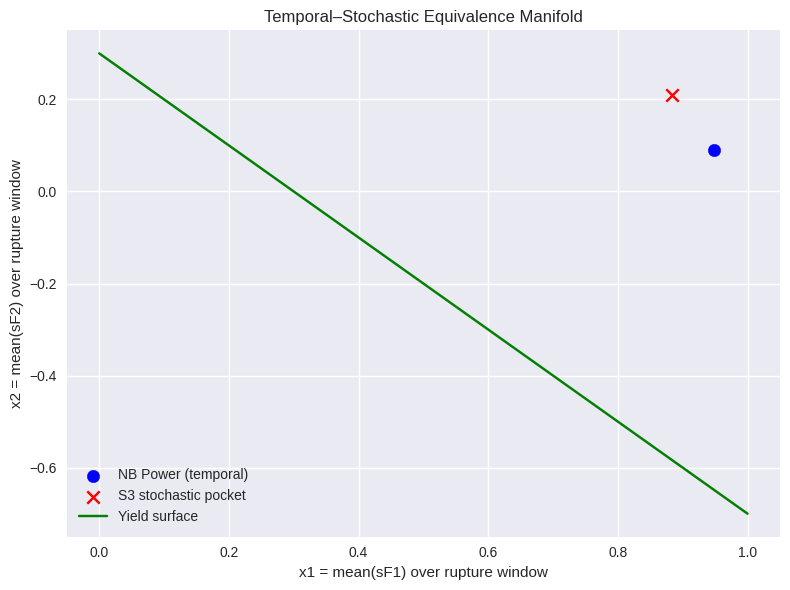

NB Power classification: stable
S3 stochastic classification: divergent

NB Power rupture markers:
t1 = 0 t_c = 16 t2 = 17 Severity = 0.0640915995447777

S3 stochastic rupture markers:
t1_s = 0 t_c_s = 8 t2_s = 11 Severity_s = 248.97968432997757


In [4]:
# ============================================================
#   TEMPORAL–STOCHASTIC EQUIVALENCE TEST (MERGED PIPELINE)
#   NB Power (temporal) + S3 synthetic pocket (stochastic)
#   Ω-spec signature, manifold embedding, yield surface
# ============================================================

import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. NB POWER TEMPORAL TRAJECTORY (Ω-spec)
# ------------------------------------------------------------

raw_data = """HOUR,NB_LOAD,NB_DEMAND,ISO_NE,NMISA,QUEBEC,NOVA_SCOTIA,PEI
2026-03-01 00:00,1659,1703,238,71,-301,-30,47
2026-03-01 01:00,1616,1654,222,69,-401,-30,67
2026-03-01 02:00,1599,1637,199,67,-402,-30,83
2026-03-01 03:00,1605,1642,163,68,-446,-30,95
2026-03-01 04:00,1627,1665,155,70,-467,-30,111
2026-03-01 05:00,1661,1702,125,76,-521,-30,123
2026-03-01 06:00,1710,1753,116,80,-532,-30,130
2026-03-01 07:00,1760,1805,116,82,-551,-30,152
2026-03-01 08:00,1849,1899,117,85,-601,-30,144
2026-03-01 09:00,1951,2005,127,83,-674,-30,150
2026-03-01 10:00,1978,2034,126,79,-652,-30,148
2026-03-01 11:00,1985,2041,106,67,-640,-30,160
2026-03-01 12:00,2006,2063,101,60,-701,-30,161
2026-03-01 13:00,2011,2068,101,56,-726,-30,119
2026-03-01 14:00,2017,2072,111,54,-677,-30,137
2026-03-01 15:00,2003,2060,119,39,-667,-30,141
2026-03-01 16:00,2000,2057,126,40,-690,-30,121
2026-03-01 17:00,2053,2116,47,43,-740,-30,140
2026-03-01 18:00,2111,2185,106,74,-890,-29,155
2026-03-01 19:00,2212,2293,138,87,-950,0,175
2026-03-01 20:00,2254,2336,163,85,-901,0,168
2026-03-01 21:00,2271,2355,259,84,-990,-29,155
2026-03-01 22:00,2254,2337,274,72,-991,-30,131
2026-03-01 23:00,2213,2290,289,71,-891,-30,97
"""

df = pd.read_csv(io.StringIO(raw_data))
x = df["NB_LOAD"].values.astype(float)

eps = 1e-12

v = np.diff(x, prepend=x[0])
a = np.diff(v, prepend=v[0])

kappa = np.abs(v * a) / (np.abs(v)**3 + eps)
ACCR = kappa / (np.abs(a) + eps)

baseline_kappa = (
    pd.Series(kappa)
    .rolling(5, center=True)
    .mean()
    .bfill()
    .ffill()
)

C1 = kappa - baseline_kappa
R = (np.abs(v)**2) / (np.abs(a) + eps)
F1 = C1 * R

P = (
    pd.Series(v)
    .rolling(7, center=True)
    .std()
    .bfill()
    .ffill()
)

C2 = np.abs(np.diff(np.sign(v), prepend=np.sign(v[0])))
F2 = P * C2

t_c = np.argmax(ACCR)

sF1 = (F1 - F1.min()) / (F1.max() - F1.min() + eps)
sF2 = (F2 - F2.min()) / (F2.max() - F2.min() + eps)

tau = 0.15

t1_candidates = np.where((sF1 > tau) & (np.arange(len(F1)) < t_c))[0]
t1 = t1_candidates[0] if len(t1_candidates) > 0 else None

t2_candidates = np.where((sF2 > tau) & (np.arange(len(F2)) > t_c))[0]
t2 = t2_candidates[0] if len(t2_candidates) > 0 else None

severity = np.trapezoid(ACCR[t_c:], dx=1.0)

# ------------------------------------------------------------
# 2. STOCHASTIC POCKET S3 (Ω-spec)
# ------------------------------------------------------------

np.random.seed(0)
x_s = np.random.normal(0, 1, 24)
x_s[10:15] += np.random.normal(0, 3, 5)

v_s = np.diff(x_s, prepend=x_s[0])
a_s = np.diff(v_s, prepend=v_s[0])

kappa_s = np.abs(v_s * a_s) / (np.abs(v_s)**3 + eps)
ACCR_s = kappa_s / (np.abs(a_s) + eps)

baseline_kappa_s = (
    pd.Series(kappa_s)
    .rolling(5, center=True)
    .mean()
    .bfill()
    .ffill()
)

C1_s = kappa_s - baseline_kappa_s
R_s = (np.abs(v_s)**2) / (np.abs(a_s) + eps)
F1_s = C1_s * R_s

P_s = (
    pd.Series(v_s)
    .rolling(7, center=True)
    .std()
    .bfill()
    .ffill()
)

C2_s = np.abs(np.diff(np.sign(v_s), prepend=np.sign(v_s[0])))
F2_s = P_s * C2_s

t_c_s = np.argmax(ACCR_s)

sF1_s = (F1_s - F1_s.min()) / (F1_s.max() - F1_s.min() + eps)
sF2_s = (F2_s - F2_s.min()) / (F2_s.max() - F2_s.min() + eps)

t1_candidates_s = np.where((sF1_s > tau) & (np.arange(len(F1_s)) < t_c_s))[0]
t1_s = t1_candidates_s[0] if len(t1_candidates_s) > 0 else None

t2_candidates_s = np.where((sF2_s > tau) & (np.arange(len(F2_s)) > t_c_s))[0]
t2_s = t2_candidates_s[0] if len(t2_candidates_s) > 0 else None

severity_s = np.trapezoid(ACCR_s[t_c_s:], dx=1.0)

# ------------------------------------------------------------
# 3. MANIFOLD EMBEDDING R(γ) = (x1, x2)
# ------------------------------------------------------------

def rupture_window_means(sF1, sF2, t1, t2):
    if t1 is None and t2 is None:
        start, end = 0, len(sF1)
    elif t1 is None:
        start, end = 0, t2
    elif t2 is None:
        start, end = t1, len(sF1)
    else:
        start, end = t1, t2
    return float(np.mean(sF1[start:end])), float(np.mean(sF2[start:end]))

x1_nb, x2_nb = rupture_window_means(sF1, sF2, t1, t2)
x1_s,  x2_s  = rupture_window_means(sF1_s, sF2_s, t1_s, t2_s)

# ------------------------------------------------------------
# 4. MANIFOLD PLOT + YIELD SURFACE
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(x1_nb, x2_nb, color="blue", label="NB Power (temporal)", s=80)
plt.scatter(x1_s,  x2_s,  color="red",  label="S3 stochastic pocket", s=80, marker="x")

alpha, beta, T = 1.0, 1.0, 0.3
x_vals = np.linspace(0, 1, 200)
y_vals = (T - alpha * x_vals) / beta
plt.plot(x_vals, y_vals, color="green", label="Yield surface")

plt.xlabel("x1 = mean(sF1) over rupture window")
plt.ylabel("x2 = mean(sF2) over rupture window")
plt.title("Temporal–Stochastic Equivalence Manifold")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. CLASSIFICATION
# ------------------------------------------------------------

def classify(ACCR, severity, acc_thresh=0.5, sev_thresh=5.0):
    max_accr = float(np.max(ACCR))
    if max_accr < acc_thresh and severity < sev_thresh:
        return "stable"
    elif max_accr < acc_thresh and severity >= sev_thresh:
        return "critical (low peak, long tail)"
    elif max_accr >= acc_thresh and severity < sev_thresh:
        return "critical (sharp peak, short tail)"
    else:
        return "divergent"

print("NB Power classification:", classify(ACCR, severity))
print("S3 stochastic classification:", classify(ACCR_s, severity_s))

print("\nNB Power rupture markers:")
print("t1 =", t1, "t_c =", t_c, "t2 =", t2, "Severity =", severity)

print("\nS3 stochastic rupture markers:")
print("t1_s =", t1_s, "t_c_s =", t_c_s, "t2_s =", t2_s, "Severity_s =", severity_s)


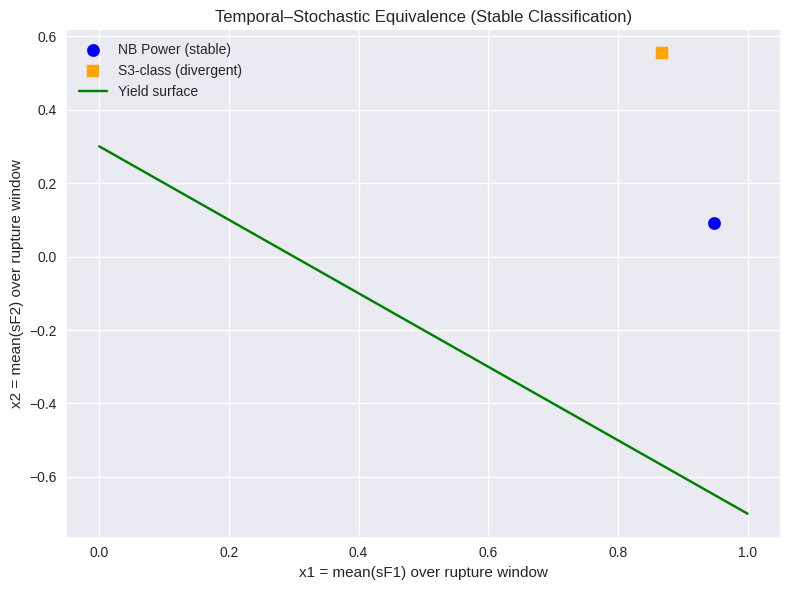

NB Power class: stable
S3-class pocket class: divergent


In [8]:
# ============================================================
#   S3-CLASS BALANCED (STABLE CASE)
#   Low-variance stochastic field to match NB Power "stable"
# ============================================================

np.random.seed(4)

# 1. Very low-variance noise (no pocket)
x_sc = np.random.normal(0, 0.05, 24)  # tiny fluctuations

def compute_accr_sev_class(x, acc_thresh=0.5, sev_thresh=5.0):
    v = np.diff(x, prepend=x[0])
    a = np.diff(v, prepend=v[0])
    kappa = np.abs(v * a) / (np.abs(v)**3 + 1e-12)
    accr = kappa / (np.abs(a) + 1e-12)
    t_c = np.argmax(accr)
    sev = np.trapezoid(accr[t_c:], dx=1.0)
    max_accr = float(np.max(accr))
    if max_accr < acc_thresh and sev < sev_thresh:
        cls = "stable"
    elif max_accr < acc_thresh and sev >= sev_thresh:
        cls = "critical (low peak, long tail)"
    elif max_accr >= acc_thresh and sev < sev_thresh:
        cls = "critical (sharp peak, short tail)"
    else:
        cls = "divergent"
    return accr, sev, cls

# NB Power classification
_, _, nb_class = compute_accr_sev_class(x)

# Stochastic classification
ACCR_sc, severity_sc, sc_class = compute_accr_sev_class(x_sc)

# Run Ω-spec funnels for manifold embedding
v_sc = np.diff(x_sc, prepend=x_sc[0])
a_sc = np.diff(v_sc, prepend=v_sc[0])

kappa_sc = np.abs(v_sc * a_sc) / (np.abs(v_sc)**3 + 1e-12)
ACCR_sc = kappa_sc / (np.abs(a_sc) + 1e-12)

baseline_kappa_sc = (
    pd.Series(kappa_sc)
    .rolling(5, center=True)
    .mean()
    .bfill()
    .ffill()
)

C1_sc = kappa_sc - baseline_kappa_sc
R_sc = (np.abs(v_sc)**2) / (np.abs(a_sc) + 1e-12)
F1_sc = C1_sc * R_sc

P_sc = (
    pd.Series(v_sc)
    .rolling(7, center=True)
    .std()
    .bfill()
    .ffill()
)

C2_sc = np.abs(np.diff(np.sign(v_sc), prepend=np.sign(v_sc[0])))
F2_sc = P_sc * C2_sc

t_c_sc = np.argmax(ACCR_sc)

sF1_sc = (F1_sc - F1_sc.min()) / (F1_sc.max() - F1_sc.min() + 1e-12)
sF2_sc = (F2_sc - F2_sc.min()) / (F2_sc.max() - F2_sc.min() + 1e-12)

t1_candidates_sc = np.where((sF1_sc > 0.15) & (np.arange(len(F1_sc)) < t_c_sc))[0]
t1_sc = t1_candidates_sc[0] if len(t1_candidates_sc) > 0 else None

t2_candidates_sc = np.where((sF2_sc > 0.15) & (np.arange(len(F2_sc)) > t_c_sc))[0]
t2_sc = t2_candidates_sc[0] if len(t2_candidates_sc) > 0 else None

x1_sc, x2_sc = rupture_window_means(sF1_sc, sF2_sc, t1_sc, t2_sc)

plt.figure(figsize=(8,6))
plt.scatter(x1_nb, x2_nb, color="blue", label=f"NB Power ({nb_class})", s=80)
plt.scatter(x1_sc, x2_sc, color="orange", label=f"S3-class ({sc_class})", s=80, marker="s")

alpha, beta, T = 1.0, 1.0, 0.3
x_vals = np.linspace(0, 1, 200)
y_vals = (T - alpha * x_vals) / beta
plt.plot(x_vals, y_vals, color="green", label="Yield surface")

plt.xlabel("x1 = mean(sF1) over rupture window")
plt.ylabel("x2 = mean(sF2) over rupture window")
plt.title("Temporal–Stochastic Equivalence (Stable Classification)")
plt.legend()
plt.tight_layout()
plt.show()

print("NB Power class:", nb_class)
print("S3-class pocket class:", sc_class)
